# PUBG Match EDA

1. Fetch one random match.
3. Inspect the raw match JSON.
4. Convert player statistics into a pandas DataFrame.
5. Download telemetry.
6. inspect event types.
7. Convert kill events into a DataFrame.
8. Perform simple exploratory data analysis.

In [ ]:

# %pip install pandas matplotlib python-dotenv requests

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from producer.api_client import PubgApiClient, PubgApiError

/Users/shouq/Downloads/pubg-streaming-platform-real-api/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Load configuration from `.env`


In [2]:
load_dotenv()

API_KEY = os.getenv("PUBG_API_KEY", "")
SHARD = os.getenv("PUBG_SHARD", "steam")

if not API_KEY:
    raise ValueError(
        "PUBG_API_KEY was not found. Make sure .env exists "
        "in the project root and contains PUBG_API_KEY."
    )

print("API key loaded:", bool(API_KEY))
print("Selected shard:", SHARD)

API key loaded: True
Selected shard: steam


## 2. Create the API client

This object handles the HTTP requests and authentication.

In [3]:
api = PubgApiClient(
    api_key=API_KEY,
    shard=SHARD,
)

print("PUBG API client is ready.")

PUBG API client is ready.


## 3. Fetch one random recent match

In [4]:
match_id = api.get_random_match_id()
print("Random match ID:", match_id)

Random match ID: a7292242-b6f8-49ee-a0b3-444d7f60f0b2


In [5]:
match_payload = api.get_match(match_id)

print("Top-level keys:", list(match_payload.keys()))
print("Number of included records:", len(match_payload.get("included", [])))

Top-level keys: ['data', 'included', 'links', 'meta']
Number of included records: 80


## 4. Inspect the raw match JSON


- `data`: information about the match itself.
- `included`: participants, rosters, and telemetry assets.
- `relationships`: links between records.

# Match Object

According to the **official PUBG API documentation**, a Match object contains information about a **completed PUBG match**, including when it occurred, the game mode, map, duration, and references to the players, teams, and assets involved.

---

## Top-Level Fields

| Field | Type | Description |
|-------|------|-------------|
| `type` | `string` | Object type. Always `"match"`. |
| `id` | `string` | Unique match identifier. |
| `attributes` | `object` | Metadata describing the match. |
| `relationships` | `object` | References to related resources such as participants, rosters, and assets. |
| `links` | `object` | API links related to this match. |

---

# attributes

| Field | Type | Description |
|-------|------|-------------|
| `createdAt` | `datetime` | Time when the match was stored in the PUBG API. |
| `duration` | `integer` | Match duration in seconds. |
| `matchType` | `string` | Type of match (e.g., official, custom, arcade). |
| `gameMode` | `string` | Game mode played (e.g., `solo`, `duo`, `squad`, `solo-fpp`, `squad-fpp`). |
| `mapName` | `string` | Name of the map where the match took place. |
| `isCustomMatch` | `boolean` | Indicates whether the match is custom. |
| `patchVersion` | `string` | Game patch version (not documented for public use). |
| `seasonState` | `string` | Season status (`prepare`, `progress`, or `closed`). |
| `shardId` | `string` | Platform shard (e.g., `steam`, `kakao`, `xbox`). |
| `stats` | `object` | Reserved field (currently undocumented). |
| `tags` | `object` | Reserved field (currently undocumented). |
| `titleId` | `string` | Identifies the game and studio. |

---

# relationships

The `relationships` section contains references to other resources included in the API response.

| Field | Description |
|-------|-------------|
| `assets` | References replay or telemetry assets associated with the match. |
| `rosters` | References the teams (rosters) that participated in the match. |
| `rounds` | Reserved field (currently undocumented). |
| `spectators` | Reserved field (currently undocumented). |

### assets.data

| Field | Type | Description |
|-------|------|-------------|
| `type` | `string` | Always `"asset"`. |
| `id` | `string` | Asset ID used to locate the complete Asset object in the `included` array. |

### rosters.data

| Field | Type | Description |
|-------|------|-------------|
| `type` | `string` | Always `"roster"`. |
| `id` | `string` | Roster ID used to locate the complete Roster object in the `included` array. |

---

# links

| Field | Type | Description |
|-------|------|-------------|
| `schema` | `string` | Reserved field (currently undocumented). |
| `self` | `string` | URL of this Match resource. |

---

## Summary

A Match object provides the **high-level metadata** for a completed PUBG match, including:

- Match information (`gameMode`, `mapName`, `matchType`)
- Timing (`createdAt`, `duration`)
- Platform information (`shardId`)
- References to participating teams (`rosters`)
- References to telemetry and other assets (`assets`)

The Match object acts as the **root object** of a match response. The actual details about players, teams, and telemetry are accessed through the objects referenced in the `relationships` section and included in the response.

In [6]:
match_payload["data"]

{'type': 'match',
 'id': 'a7292242-b6f8-49ee-a0b3-444d7f60f0b2',
 'attributes': {'mapName': 'Baltic_Main',
  'matchType': 'competitive',
  'seasonState': 'progress',
  'createdAt': '2026-07-12T15:44:11Z',
  'duration': 1454,
  'stats': None,
  'gameMode': 'squad',
  'shardId': 'steam',
  'isCustomMatch': False,
  'titleId': 'bluehole-pubg',
  'tags': None},
 'relationships': {'rosters': {'data': [{'type': 'roster',
     'id': 'c8b8880d-dc13-41e2-8ebc-9d40d38cad75'},
    {'type': 'roster', 'id': '98cd0850-57c1-4d35-a733-79febfe501c3'},
    {'type': 'roster', 'id': '19925003-716d-4a01-b0d5-89eb7e2378d4'},
    {'type': 'roster', 'id': '56817730-da7a-4006-a18d-074e3c2c6d22'},
    {'type': 'roster', 'id': '9cabdb4c-686f-453e-a12b-26ad09febdf1'},
    {'type': 'roster', 'id': '9c227b0b-1712-47ba-86ef-f5e9a3aa4c68'},
    {'type': 'roster', 'id': '3032ffcf-7c1f-4a2e-a233-1b1bcbc262ad'},
    {'type': 'roster', 'id': 'e5538ed2-3ed9-4788-801f-adde313b8ff8'},
    {'type': 'roster', 'id': '3da62c9d-

# Participant Object

Represents a **player within a specific match**. A Participant object only exists in the context of a match and is **not available as a standalone resource**.

## Top-Level Fields

| Field | Type | Description |
|-------|------|-------------|
| `type` | `string` | Object type. Always `"participant"`. |
| `id` | `string` | Randomly generated identifier used to link this participant within the match response. |
| `attributes` | `object` | Contains participant information. |

---

## attributes

| Field | Type | Description |
|-------|------|-------------|
| `actor` | `string` | Internal field (not documented for public use). |
| `shardId` | `string` | Platform shard (e.g., `steam`, `kakao`, `xbox`). |
| `stats` | `object` | Statistics for this player during the match. |

---

# attributes.stats

| Field | Type | Description |
|-------|------|-------------|
| `DBNOs` | `integer` | Number of players knocked (Down But Not Out). |
| `assists` | `integer` | Number of enemies damaged by this player but killed by teammates. |
| `boosts` | `integer` | Number of boost items used. |
| `damageDealt` | `number` | Total damage dealt (self-inflicted damage is subtracted). |
| `deathType` | `string` | How the player died (or `"alive"` if they survived). |
| `headshotKills` | `integer` | Number of kills achieved with headshots. |
| `heals` | `integer` | Number of healing items used. |
| `killPlace` | `integer` | Rank in the match based on kills. |
| `killStreaks` | `integer` | Number of kill streaks. |
| `kills` | `integer` | Number of enemy players killed. |
| `longestKill` | `number` | Longest kill distance (meters). |
| `name` | `string` | Player's in-game name (IGN). |
| `playerId` | `string` | PUBG account ID. |
| `revives` | `integer` | Number of teammates revived. |
| `rideDistance` | `number` | Distance traveled in vehicles (meters). |
| `roadKills` | `integer` | Number of kills made while using a vehicle. |
| `swimDistance` | `number` | Distance traveled while swimming (meters). |
| `teamKills` | `integer` | Number of teammates killed. |
| `timeSurvived` | `number` | Survival time (seconds). |
| `vehicleDestroys` | `integer` | Number of vehicles destroyed. |
| `walkDistance` | `number` | Distance traveled on foot (meters). |
| `weaponsAcquired` | `integer` | Number of weapons picked up. |
| `winPlace` | `integer` | Final placement in the match. |

---

## Summary

A Participant object represents **one player's performance in one match**, including:

- Player identity (`name`, `playerId`)
- Combat statistics (`kills`, `damageDealt`, `assists`, `headshotKills`)
- Survival (`timeSurvived`, `deathType`, `winPlace`)
- Movement (`walkDistance`, `rideDistance`, `swimDistance`)
- Team interactions (`revives`, `teamKills`)
- Looting (`weaponsAcquired`, `boosts`, `heals`)

included: A top-level array containing the complete related objects (e.g., participants, rosters, and assets) referenced by the Match object's relationships.

In [8]:
match_payload

{'data': {'type': 'match',
  'id': 'a7292242-b6f8-49ee-a0b3-444d7f60f0b2',
  'attributes': {'mapName': 'Baltic_Main',
   'matchType': 'competitive',
   'seasonState': 'progress',
   'createdAt': '2026-07-12T15:44:11Z',
   'duration': 1454,
   'stats': None,
   'gameMode': 'squad',
   'shardId': 'steam',
   'isCustomMatch': False,
   'titleId': 'bluehole-pubg',
   'tags': None},
  'relationships': {'rosters': {'data': [{'type': 'roster',
      'id': 'c8b8880d-dc13-41e2-8ebc-9d40d38cad75'},
     {'type': 'roster', 'id': '98cd0850-57c1-4d35-a733-79febfe501c3'},
     {'type': 'roster', 'id': '19925003-716d-4a01-b0d5-89eb7e2378d4'},
     {'type': 'roster', 'id': '56817730-da7a-4006-a18d-074e3c2c6d22'},
     {'type': 'roster', 'id': '9cabdb4c-686f-453e-a12b-26ad09febdf1'},
     {'type': 'roster', 'id': '9c227b0b-1712-47ba-86ef-f5e9a3aa4c68'},
     {'type': 'roster', 'id': '3032ffcf-7c1f-4a2e-a233-1b1bcbc262ad'},
     {'type': 'roster', 'id': 'e5538ed2-3ed9-4788-801f-adde313b8ff8'},
     {'ty

In [25]:
for key in match_payload:
    print(key)

data
included
links
meta


In [7]:
# Display only the first included record.
match_payload.get("included", [])[0]

{'type': 'participant',
 'id': 'c1692eb6-8db8-4910-a088-951f185e1e6f',
 'attributes': {'stats': {'DBNOs': 0,
   'assists': 1,
   'boosts': 2,
   'damageDealt': 98.96219,
   'deathType': 'byplayer',
   'headshotKills': 0,
   'heals': 3,
   'killPlace': 26,
   'killStreaks': 1,
   'kills': 1,
   'longestKill': 6.3307757,
   'name': 'JAY-197986',
   'playerId': 'account.01aa09ab6c3f43e1965144f60c673aeb',
   'revives': 1,
   'rideDistance': 0,
   'roadKills': 0,
   'swimDistance': 0,
   'teamKills': 0,
   'timeSurvived': 478,
   'vehicleDestroys': 0,
   'walkDistance': 851.0247,
   'weaponsAcquired': 8,
   'winPlace': 13},
  'actor': '',
  'shardId': 'steam'}}

In [11]:
match_payload.get("included", [])[1]

{'type': 'participant',
 'id': '8649d2ed-a36e-4916-952f-1b20e350eeb8',
 'attributes': {'stats': {'DBNOs': 2,
   'assists': 0,
   'boosts': 2,
   'damageDealt': 228.82921,
   'deathType': 'byplayer',
   'headshotKills': 1,
   'heals': 0,
   'killPlace': 18,
   'killStreaks': 1,
   'kills': 2,
   'longestKill': 18.019127,
   'name': '1-9527-',
   'playerId': 'account.e9d235ac12d14c5780ab5697ebe1c864',
   'revives': 0,
   'rideDistance': 0,
   'roadKills': 0,
   'swimDistance': 0,
   'teamKills': 0,
   'timeSurvived': 306,
   'vehicleDestroys': 0,
   'walkDistance': 385.10938,
   'weaponsAcquired': 5,
   'winPlace': 16},
  'actor': '',
  'shardId': 'steam'}}

In [18]:
match_payload.get("included", [])[63]

{'type': 'participant',
 'id': 'a35335ca-6ffe-4d0f-9a1a-fd3251e0a2c7',
 'attributes': {'stats': {'DBNOs': 0,
   'assists': 0,
   'boosts': 0,
   'damageDealt': 0,
   'deathType': 'byplayer',
   'headshotKills': 0,
   'heals': 0,
   'killPlace': 60,
   'killStreaks': 0,
   'kills': 0,
   'longestKill': 0,
   'name': 'Four-4Hours_',
   'playerId': 'account.7840cc87d87c46f1afbf438f71c7baf5',
   'revives': 0,
   'rideDistance': 0,
   'roadKills': 0,
   'swimDistance': 0,
   'teamKills': 0,
   'timeSurvived': 158,
   'vehicleDestroys': 0,
   'walkDistance': 281.9674,
   'weaponsAcquired': 1,
   'winPlace': 17},
  'actor': '',
  'shardId': 'steam'}}

## 5. Explore the types of included records

This shows how many participants, rosters, and assets exist in the response.

In [21]:
for item in match_payload.get("included", []):
    print(item)

{'type': 'participant', 'id': 'c1692eb6-8db8-4910-a088-951f185e1e6f', 'attributes': {'stats': {'DBNOs': 0, 'assists': 1, 'boosts': 2, 'damageDealt': 98.96219, 'deathType': 'byplayer', 'headshotKills': 0, 'heals': 3, 'killPlace': 26, 'killStreaks': 1, 'kills': 1, 'longestKill': 6.3307757, 'name': 'JAY-197986', 'playerId': 'account.01aa09ab6c3f43e1965144f60c673aeb', 'revives': 1, 'rideDistance': 0, 'roadKills': 0, 'swimDistance': 0, 'teamKills': 0, 'timeSurvived': 478, 'vehicleDestroys': 0, 'walkDistance': 851.0247, 'weaponsAcquired': 8, 'winPlace': 13}, 'actor': '', 'shardId': 'steam'}}
{'type': 'participant', 'id': '8649d2ed-a36e-4916-952f-1b20e350eeb8', 'attributes': {'stats': {'DBNOs': 2, 'assists': 0, 'boosts': 2, 'damageDealt': 228.82921, 'deathType': 'byplayer', 'headshotKills': 1, 'heals': 0, 'killPlace': 18, 'killStreaks': 1, 'kills': 2, 'longestKill': 18.019127, 'name': '1-9527-', 'playerId': 'account.e9d235ac12d14c5780ab5697ebe1c864', 'revives': 0, 'rideDistance': 0, 'roadKill

In [19]:
included_types = pd.Series(
    [
        item.get("type")
        for item in match_payload.get("included", [])
    ]
)

included_types.value_counts()

participant    62
roster         17
asset           1
Name: count, dtype: int64

## 6. Convert player statistics into a DataFrame

In [26]:
players = api.get_match_players(match_payload)
players_df = pd.DataFrame(players)

print("Player rows:", len(players_df))
players_df.head(10)

Player rows: 62


,participant_id,player_id,name,kills,damage_dealt,win_place,time_survived
0,c1692eb6-8db8-4910-a088-951f185e1e6f,account.01aa09ab6c3f43e1965144f60c673aeb,JAY-197986,1,98.96219,13,478
1,8649d2ed-a36e-4916-952f-1b20e350eeb8,account.e9d235ac12d14c5780ab5697ebe1c864,1-9527-,2,228.82921,16,306
2,23872451-4c22-4b68-84b6-a375bdc4edba,account.68c2a6e309c840c88d24237f10181673,Wait_up_kZz,6,622.45844,4,1317
3,91896add-8fff-4eac-bc4f-e2dac3361a72,account.e1ebcc1a34514fc1809b20192d073c42,YF_phillips,0,0.00000,9,692
4,923ee9d2-aa3c-4cd8-bb92-0866962351e9,account.6febcff836fb4117a66ef77e056ef5ee,infit____,0,124.30990,15,334
5,549e80e0-89c5-4d3b-b9f0-f5d6c0f7c214,account.d4c53ab2acc045838def37f935608c86,KILL-ZHANGYE,4,544.71410,1,1454
6,3d5e731d-b0b7-425e-a0dd-352e0da5269b,account.3c0565a8a2aa4faaa71d73975563522a,779OVO_-,2,353.31653,1,1454
7,57a4abe9-5ac6-41e4-ae70-753174c46829,account.e129c8c9c0b44138a78992b226db1f12,KoreanD,2,249.21548,4,1401
8,a42f0c61-8e1d-48a6-8bc8-14913a327169,account.aa4f5e5b12f34c25b4ed3fd59a0dbd75,SHEJIANLIN,1,99.99999,10,515
9,56f557e6-65d4-442b-860a-48dea97afc49,account.57e5af06ebb64e1eb9e44116685893f8,NONAME_RD11518,0,143.87500,10,763


In [27]:
players_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   participant_id  62 non-null     object 
 1   player_id       62 non-null     object 
 2   name            62 non-null     object 
 3   kills           62 non-null     int64  
 4   damage_dealt    62 non-null     float64
 5   win_place       62 non-null     int64  
 6   time_survived   62 non-null     int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 3.5+ KB


In [28]:
players_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,62,62,c1692eb6-8db8-4910-a088-951f185e1e6f,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
player_id,62,62,account.01aa09ab6c3f43e1965144f60c673aeb,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,62,62,JAY-197986,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kills,62.0,NaN,NaN,NaN,1.016129,1.396623,0.0,0.0,0.0,2.0,6.0
damage_dealt,62.0,NaN,NaN,NaN,177.466803,193.858451,0.0,3.726498,125.35495,284.24955,830.5624
win_place,62.0,NaN,NaN,NaN,9.145161,5.066272,1.0,4.25,9.5,13.0,17.0
time_survived,62.0,NaN,NaN,NaN,769.935484,453.284114,103.0,382.0,730.5,1191.75,1454.0


## 7. Basic player EDA

In [29]:
players_df.isna().sum().sort_values(ascending=False)

participant_id    0
player_id         0
name              0
kills             0
damage_dealt      0
win_place         0
time_survived     0
dtype: int64

In [30]:
players_df.sort_values(
    by=["kills", "damage_dealt"],
    ascending=[False, False],
).head(10)

,participant_id,player_id,name,kills,damage_dealt,win_place,time_survived
2,23872451-4c22-4b68-84b6-a375bdc4edba,account.68c2a6e309c840c88d24237f10181673,Wait_up_kZz,6,622.45844,4,1317
5,549e80e0-89c5-4d3b-b9f0-f5d6c0f7c214,account.d4c53ab2acc045838def37f935608c86,KILL-ZHANGYE,4,544.71410,1,1454
12,759b0e6a-a712-4c44-bb3b-6a8b7ddc48a5,account.8d8cba51744641708c7e3ab0131eb0e8,GTM_13shu,4,465.35266,3,1378
35,485c4252-5cd1-405f-b07c-2d99da6c1414,account.fbea55302af9466bad2f5740f97379af,HeHe_PLUS,4,416.15906,14,382
59,e9e9e1e0-a74d-4921-a16d-e6eeadbd89a3,account.d084307c7e814cb3b949ffb57e3906ad,BMW_Coastline,4,290.60000,10,788
60,a4964a2c-de5e-4bab-878f-0e087aa16bc3,account.59171b01cdcb43e58cf1384b6a73a270,Zi_mumumu,3,830.56240,6,1176
32,7b3b011e-0a21-4101-9b63-f66a7cb16a87,account.399b8d5e6526435b9fadfa6b1c61a1cf,MMIAO66-,3,345.02856,3,1443
14,eba80084-a5b8-430c-9eee-bfe0cae7c696,account.a74c1423ef8d4fb8ad3d6aa2d6d4547a,Acz-AP,3,312.69086,8,1014
46,3b7773eb-3ecb-444c-b90a-5936aac6d742,account.1e84ab2b17ec42a5ad40cb2bc3fcc0ca,RollsRoyce-_o,3,265.19820,2,1431
45,76e11fd4-f4f4-4190-a474-125968467e87,account.709b051db7a44682a76b9b2c6ba104e4,Rabbitww,2,768.48410,1,1454


In [33]:
players_df["kills"].value_counts().sort_index()  # 33 players got 0 kills

kills
0    33
1    11
2     9
3     4
4     4
6     1
Name: count, dtype: int64

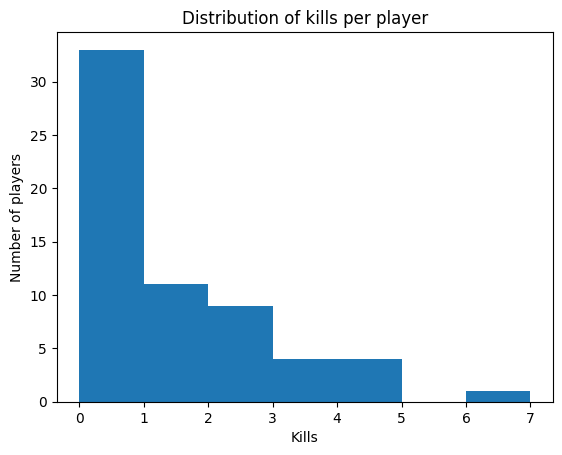

In [34]:
players_df["kills"].plot(
    kind="hist",
    bins=range(
        0,
        int(players_df["kills"].max() or 0) + 2,
    ),
    title="Distribution of kills per player",
)

plt.xlabel("Kills")
plt.ylabel("Number of players")
plt.show()

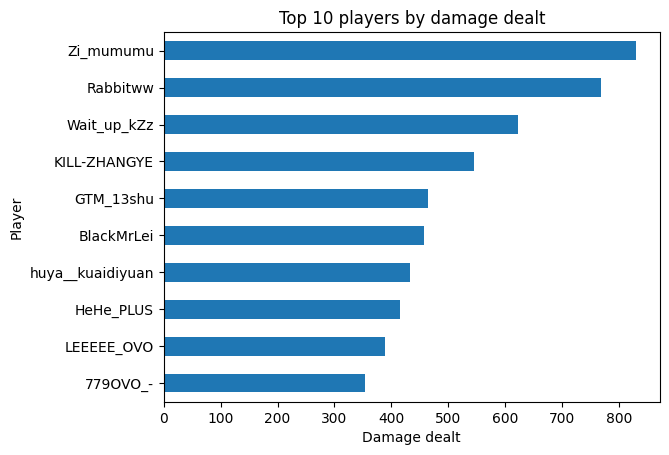

In [35]:
top_damage = (
    players_df
    .dropna(subset=["name", "damage_dealt"])
    .nlargest(10, "damage_dealt")
    .sort_values("damage_dealt")
)

top_damage.plot(
    kind="barh",
    x="name",
    y="damage_dealt",
    legend=False,
    title="Top 10 players by damage dealt",
)

plt.xlabel("Damage dealt")
plt.ylabel("Player")
plt.show()

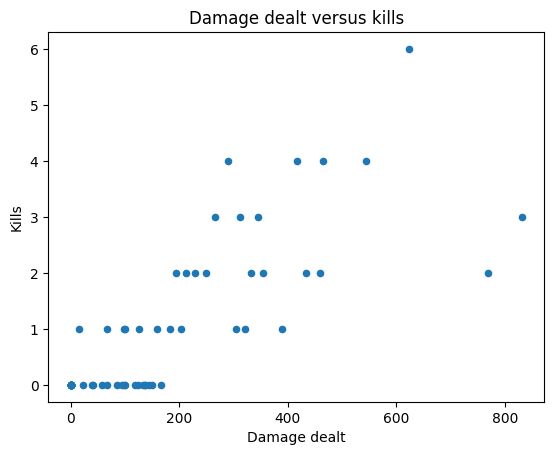

In [36]:
players_df.plot(
    kind="scatter",
    x="damage_dealt",
    y="kills",
    title="Damage dealt versus kills",
)

plt.xlabel("Damage dealt")
plt.ylabel("Kills")
plt.show()

## 8. Download telemetry

Telemetry contains detailed events that happened during the match.

Examples include:

- player positions
- attacks
- damage
- kills
- item pickups
- vehicle events
- match start and end events

In [37]:
telemetry_url = api.get_telemetry_url(match_payload)
print("Telemetry URL found:", bool(telemetry_url))

telemetry = api.get_telemetry(telemetry_url)
print("Telemetry event count:", len(telemetry))

Telemetry URL found: True
Telemetry event count: 34136


## 9. Inspect raw telemetry events

In [38]:
telemetry[0]

{'_T': 'LogMatchDefinition',
 'MatchId': 'match.bro.competitive.pc-2018-42.steam.squad.as.2026.07.12.15.a7292242-b6f8-49ee-a0b3-444d7f60f0b2',
 'PingQuality': '',
 '_D': '2026-07-12T15:44:11.2561693Z'}

## 10. Count telemetry event types

The `_T` field is the event type.

In [40]:
event_type_counts = (
    pd.Series(
        [event.get("_T") for event in telemetry],
        name="event_type",
    )
    .value_counts()
    .rename_axis("event_type")
    .reset_index(name="event_count")
)

event_type_counts.head(20)

,event_type,event_count
0,LogHeal,5870
1,LogPlayerPosition,5362
2,LogPlayerAttack,4604
3,LogPlayerTakeDamage,4077
4,LogItemPickup,3697
5,LogItemEquip,1414
6,LogItemUnequip,1161
7,LogItemUse,1043
8,LogObjectInteraction,906
9,LogItemAttach,894


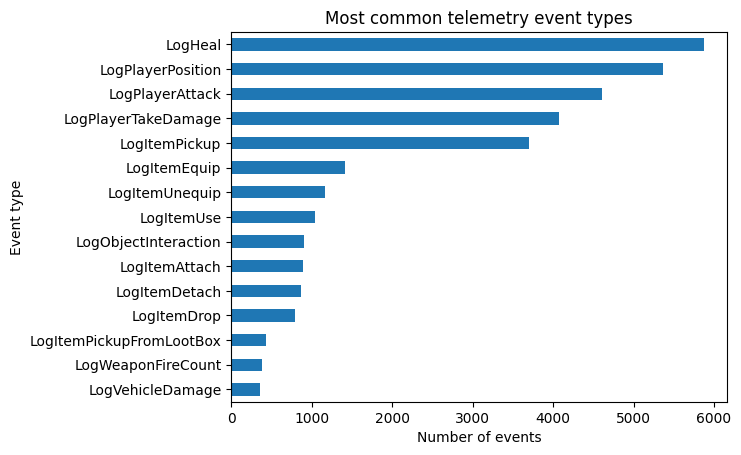

In [41]:
event_type_counts.head(15).sort_values("event_count").plot(
    kind="barh",
    x="event_type",
    y="event_count",
    legend=False,
    title="Most common telemetry event types",
)

plt.xlabel("Number of events")
plt.ylabel("Event type")
plt.show()

## 11. Inspect one kill event

In [42]:
raw_kill_events = [
    event
    for event in telemetry
    if event.get("_T") == "LogPlayerKillV2"
]

print("Kill event count:", len(raw_kill_events))

raw_kill_events[0] if raw_kill_events else "No kill events found"

Kill event count: 64


{'_T': 'LogPlayerKillV2',
 'attackId': 771752056,
 'dBNOId': 150994944,
 'victimGameResult': {'rank': 0,
  'gameResult': '',
  'teamId': 1,
  'stats': {'killCount': 0,
   'distanceOnFoot': 36.52305221557617,
   'distanceOnSwim': 0,
   'distanceOnVehicle': 0,
   'distanceOnParachute': 334.47198486328125,
   'distanceOnFreefall': 1436.6424560546875,
   'bpRewardDetail': {'byPlayTime': 0,
    'byRanking': 0,
    'byKills': 0,
    'byDamageDealt': 0,
    'boostAmount': 0,
    'byModeScore': 0},
   'arcadeRewardDetail': {'byPlayTime': 0},
   'statTrakDataPairs': [{'gameItemId': 'Item_Skin_MP5K_25PNC_01_C',
     'value': 217},
    {'gameItemId': 'Item_Skin_M762_2602_01_C', 'value': 39},
    {'gameItemId': 'Item_Skin_SKS_Apocalypse_01_C', 'value': 12},
    {'gameItemId': 'Item_Skin_M1897_2505_01_C', 'value': 143},
    {'gameItemId': 'Item_Skin_Saiga12_2408_01_C', 'value': 68},
    {'gameItemId': 'Item_Skin_M249_2409_01_C', 'value': 25},
    {'gameItemId': 'Item_Skin_Mini14_Apocalypse_02_C', '

## 12. Convert kill events into a DataFrame

This reproduces the useful fields from your Kafka producer, but keeps the data inside the notebook.

In [43]:
def character_name(
    character: dict[str, Any] | None,
) -> str:
    if not character:
        return "Environment"

    return character.get("name") or "Unknown"


def flatten_kill_event(
    raw_event: dict[str, Any],
    match_id: str,
    telemetry_index: int,
) -> dict[str, Any]:
    killer = raw_event.get("killer")
    victim = raw_event.get("victim") or {}

    damage_info = (
        raw_event.get("killerDamageInfo")
        or raw_event.get("finishDamageInfo")
        or raw_event.get("dBNODamageInfo")
        or {}
    )

    return {
        "telemetry_index": telemetry_index,
        "event_type": raw_event.get("_T"),
        "event_time": raw_event.get("_D"),
        "match_id": match_id,
        "killer": character_name(killer),
        "killer_account_id": (
            killer.get("accountId")
            if killer
            else None
        ),
        "killer_team_id": (
            killer.get("teamId")
            if killer
            else None
        ),
        "victim": character_name(victim),
        "victim_account_id": victim.get("accountId"),
        "victim_team_id": victim.get("teamId"),
        "weapon_raw": (
            damage_info.get("damageCauserName")
            or "Unknown"
        ),
        "damage_reason_raw": damage_info.get(
            "damageReason"
        ),
        "damage_type_raw": damage_info.get(
            "damageTypeCategory"
        ),
        "distance_raw_cm": float(
            damage_info.get("distance") or 0
        ),
        "is_headshot": (
            damage_info.get("damageReason")
            == "HeadShot"
        ),
        "is_suicide": bool(
            raw_event.get("isSuicide")
        ),
        "assist_count": len(
            raw_event.get(
                "assists_AccountId",
                [],
            )
            or []
        ),
    }

In [44]:
kill_rows = [
    flatten_kill_event(
        raw_event=event,
        match_id=match_id,
        telemetry_index=index,
    )
    for index, event in enumerate(telemetry)
    if event.get("_T") == "LogPlayerKillV2"
]

kills_df = pd.DataFrame(kill_rows)

print("Kill rows:", len(kills_df))
kills_df.head(10)

Kill rows: 64


,telemetry_index,event_type,event_time,match_id,killer,killer_account_id,killer_team_id,victim,victim_account_id,victim_team_id,weapon_raw,damage_reason_raw,damage_type_raw,distance_raw_cm,is_headshot,is_suicide,assist_count
0,2793,LogPlayerKillV2,2026-07-12T15:45:54.578Z,a7292242-b6f8-49ee-a0b3-444d7f60f0b2,Patrickstar8705,account.6a335337a0944ce9a616b1ed7099149c,14.0,4T_LOLO,account.1db0b3f186114505970702f2d5b05aca,1,WeapSaiga12_C,PelvisShot,Damage_Gun,1336.498169,False,False,1
1,2988,LogPlayerKillV2,2026-07-12T15:45:57.524Z,a7292242-b6f8-49ee-a0b3-444d7f60f0b2,BlackMrLei,account.2ac415fc11984341a81c606b6e59473f,5.0,KG-DaBao86,account.839d0c5f88194c55926e451feb6ee997,10,WeapAK47_C,ArmShot,Damage_Gun,276.826447,False,False,0
2,4407,LogPlayerKillV2,2026-07-12T15:46:25.742Z,a7292242-b6f8-49ee-a0b3-444d7f60f0b2,BlackMrLei,account.2ac415fc11984341a81c606b6e59473f,5.0,king-hjj123,account.78314fe101a54104903848cd6abadb5a,10,WeapAK47_C,ArmShot,Damage_Gun,871.317200,False,False,0
3,4715,LogPlayerKillV2,2026-07-12T15:46:31.323Z,a7292242-b6f8-49ee-a0b3-444d7f60f0b2,BMW_Coastline,account.d084307c7e814cb3b949ffb57e3906ad,5.0,0gaioce5h,account.f8aa3dcc5ec44a4b9f06bb6ce8d120fd,10,WeapMP5K_C,ArmShot,Damage_Gun,2410.540771,False,False,1
4,5415,LogPlayerKillV2,2026-07-12T15:46:49.744Z,a7292242-b6f8-49ee-a0b3-444d7f60f0b2,SHEJIANLIN,account.aa4f5e5b12f34c25b4ed3fd59a0dbd75,5.0,Four-4Hours_,account.7840cc87d87c46f1afbf438f71c7baf5,10,WeapSCAR-L_C,TorsoShot,Damage_Gun,2944.209961,False,False,0
5,6332,LogPlayerKillV2,2026-07-12T15:47:12.164Z,a7292242-b6f8-49ee-a0b3-444d7f60f0b2,HeHe_PLUS,account.fbea55302af9466bad2f5740f97379af,16.0,dsz940,account.dd06ecd7c643419784febf371294febb,2,WeapACE32_C,LegShot,Damage_Gun,5548.497070,False,False,0
6,7174,LogPlayerKillV2,2026-07-12T15:47:34.778Z,a7292242-b6f8-49ee-a0b3-444d7f60f0b2,1-9527-,account.e9d235ac12d14c5780ab5697ebe1c864,2.0,Lgulang,account.9cbe64953171415f956acddd379ccd8d,4,WeapUZI_C,ArmShot,Damage_Gun,488.442322,False,False,0
7,7649,LogPlayerKillV2,2026-07-12T15:47:45.027Z,a7292242-b6f8-49ee-a0b3-444d7f60f0b2,huya__kuaidiyuan,account.ae230edbf99d47b1bbd4f665a7bd6c6e,4.0,imDouYu926213,account.3d057507a5784d3ca03952477cc60171,2,WeapACE32_C,HeadShot,Damage_Gun,1662.811157,True,False,0
8,10116,LogPlayerKillV2,2026-07-12T15:48:58.158Z,a7292242-b6f8-49ee-a0b3-444d7f60f0b2,HeHe_PLUS,account.fbea55302af9466bad2f5740f97379af,16.0,Honeybaby_Mia,account.0a038d7e0b3f4cdab7e27c6bcb49dbd1,4,WeapACE32_C,TorsoShot,Damage_Gun,4729.621582,False,False,0
9,10556,LogPlayerKillV2,2026-07-12T15:49:11.085Z,a7292242-b6f8-49ee-a0b3-444d7f60f0b2,Wait_up_kZz,account.68c2a6e309c840c88d24237f10181673,12.0,Agony-c,account.645cb66931de4d189c1c45098f9a2027,14,PanzerFaust100M_Projectile_C,NonSpecific,Damage_Explosion_PanzerFaustWarhead,705.068298,False,False,0


## 13. Clean useful fields

PUBG telemetry distance is stored in centimeters.

This creates a distance field in meters.

In [45]:
if not kills_df.empty:
    kills_df["event_time"] = pd.to_datetime(
        kills_df["event_time"],
        utc=True,
        errors="coerce",
    )

    kills_df["distance_meters"] = (
        kills_df["distance_raw_cm"] / 100
    )

kills_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   telemetry_index    64 non-null     int64              
 1   event_type         64 non-null     object             
 2   event_time         64 non-null     datetime64[ns, UTC]
 3   match_id           64 non-null     object             
 4   killer             64 non-null     object             
 5   killer_account_id  63 non-null     object             
 6   killer_team_id     63 non-null     float64            
 7   victim             64 non-null     object             
 8   victim_account_id  64 non-null     object             
 9   victim_team_id     64 non-null     int64              
 10  weapon_raw         64 non-null     object             
 11  damage_reason_raw  64 non-null     object             
 12  damage_type_raw    64 non-null     object           

## 14. Kill-event EDA

In [46]:
kills_df.isna().sum().sort_values(ascending=False)

killer_account_id    1
killer_team_id       1
telemetry_index      0
weapon_raw           0
assist_count         0
is_suicide           0
is_headshot          0
distance_raw_cm      0
damage_type_raw      0
damage_reason_raw    0
victim_team_id       0
event_type           0
victim_account_id    0
victim               0
killer               0
match_id             0
event_time           0
distance_meters      0
dtype: int64

In [47]:
kills_df["weapon_raw"].value_counts().head(15)

weapon_raw
WeapBerylM762_C                 13
WeapACE32_C                      8
WeapM24_C                        5
ProjGrenade_C                    4
WeapMini14_C                     4
WeapAK47_C                       3
WeapMk12_C                       3
WeapAUG_C                        3
WeapM249_C                       2
PanzerFaust100M_Projectile_C     2
WeapUMP_C                        2
WeapMP5K_C                       2
WeapKar98k_C                     2
WeapHK416_C                      1
Uaz_C_01_C                       1
Name: count, dtype: int64

In [48]:
kills_df["damage_reason_raw"].value_counts(dropna=False)

damage_reason_raw
HeadShot       16
ArmShot        12
TorsoShot      12
NonSpecific    10
LegShot         8
PelvisShot      5
                1
Name: count, dtype: int64

In [49]:
kills_df[["distance_meters", "assist_count"]].describe()

,distance_meters,assist_count
count,64.000000,64.00000
mean,58.362000,0.56250
std,68.213927,0.61399
min,-0.010000,0.00000
25%,13.128557,0.00000
50%,32.198247,0.50000
75%,77.203115,1.00000
max,287.058027,2.00000


In [50]:
kills_df[
    [
        "killer",
        "victim",
        "weapon_raw",
        "damage_reason_raw",
        "distance_meters",
        "is_headshot",
        "is_suicide",
    ]
].sort_values(
    "distance_meters",
    ascending=False,
).head(10)

,killer,victim,weapon_raw,damage_reason_raw,distance_meters,is_headshot,is_suicide
24,GTM_13shu,83spiteful38,WeapM24_C,TorsoShot,287.058027,False,False
27,Acz-AP,buyaon1,WeapMk12_C,HeadShot,260.361270,True,False
32,Zi_mumumu,66-PGone,WeapKar98k_C,ArmShot,251.164922,False,False
57,Rabbitww,heaven2001,WeapMini14_C,TorsoShot,200.651816,False,False
58,KILL-ZHANGYE,KoreanD,WeapM24_C,TorsoShot,185.606074,False,False
59,KILL-ZHANGYE,Seol_O_O,WeapM24_C,ArmShot,174.896465,False,False
19,tao_9158,SHEJIANLIN,WeapMk12_C,HeadShot,166.934180,True,False
13,Wait_up_kZz,Patrickstar8705,WeapAK47_C,LegShot,153.383398,False,False
41,Biehua-0523,YExyy,WeapMk12_C,ArmShot,138.853545,False,False
52,KoreanD,huya__kuaidiyuan,WeapMini14_C,HeadShot,113.011133,True,False


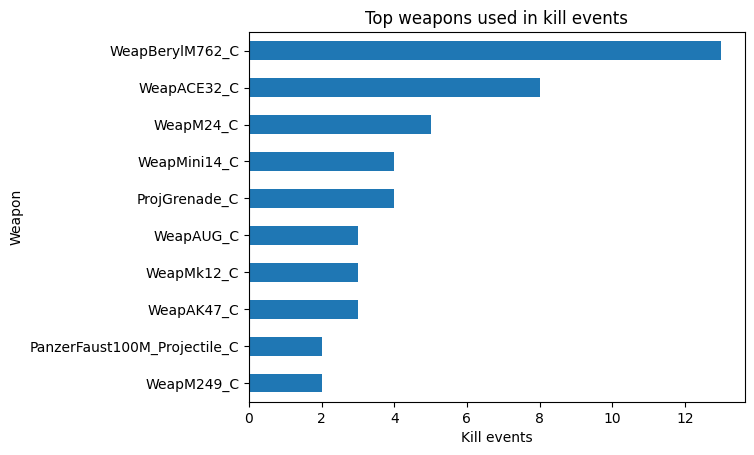

In [51]:
kills_df["weapon_raw"].value_counts().head(10).sort_values().plot(
    kind="barh",
    title="Top weapons used in kill events",
)

plt.xlabel("Kill events")
plt.ylabel("Weapon")
plt.show()

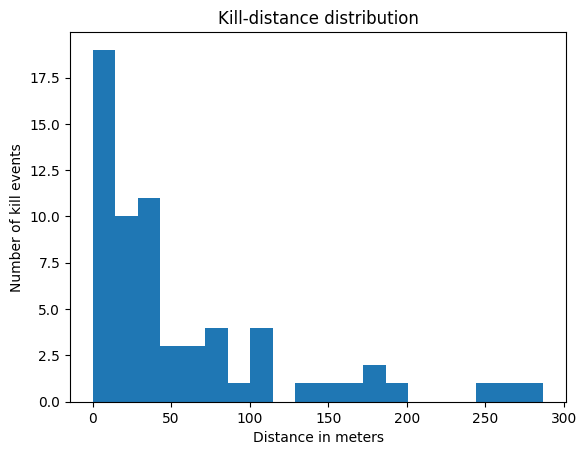

In [52]:
kills_df["distance_meters"].plot(
    kind="hist",
    bins=20,
    title="Kill-distance distribution",
)

plt.xlabel("Distance in meters")
plt.ylabel("Number of kill events")
plt.show()

In [53]:
headshot_summary = (
    kills_df["is_headshot"]
    .value_counts(dropna=False)
    .rename_axis("is_headshot")
    .reset_index(name="kill_count")
)

headshot_summary

,is_headshot,kill_count
0,False,48
1,True,16


In [55]:
output_directory = Path("data/eda")
output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

players_path = output_directory / f"{match_id}_players.csv"
kills_path = output_directory / f"{match_id}_kills.csv"
telemetry_path = output_directory / f"{match_id}_telemetry.json"

players_df.to_csv(
    players_path,
    index=False,
)

kills_df.to_csv(
    kills_path,
    index=False,
)

with telemetry_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        telemetry,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved:", players_path)
print("Saved:", kills_path)
print("Saved:", telemetry_path)

Saved: data/eda/a7292242-b6f8-49ee-a0b3-444d7f60f0b2_players.csv
Saved: data/eda/a7292242-b6f8-49ee-a0b3-444d7f60f0b2_kills.csv
Saved: data/eda/a7292242-b6f8-49ee-a0b3-444d7f60f0b2_telemetry.json


## 15. Questions to answer during EDA


- How many players participated?
- Who had the most kills?
- Who dealt the most damage?
- Which weapon produced the most kill events?
- What percentage of kills were headshots?
- How many deaths were caused by the environment?
- What was the longest kill distance?
- Are higher damage values generally associated with more kills?
- Which telemetry event types occur most often?


1. inspecting,
2. questioning,
3. cleaning,
4. summarizing,
5. visualizing,
6. validating.